![delensalot logo](./../../res/delensalot_logo_new.PNG)

# Interactive joint-MAP minimal working example - full sky
In this notebook, you perfrom [QE](https://arxiv.org/abs/1807.06210) and [iterative reconstruction](https://arxiv.org/abs/2310.06729) for a single simulation, and for the full sky, jointly for the lensing gradient, curl, and anisotropic birefringence.

The simulations are created upon runtime inclusive of isotropic white noise and without foregrounds, using a built-in CMB-simulations module.
At the end of this tutorial, you will plot the reconstructed fields of the lensing gradient, curl, and birefringence, and calculate a residual lensing amplitude from delensed B-maps.

All parameters are set via a configuration file [here](./conf_mwe_jMAP_fullsky.py), and you can freely change the parameters to your liking.


In [ ]:
from delensalot.run import run
from delensalot.utils import camb_clfile
from delensalot.core.MAP.context import get_computation_context
from IPython.display import clear_output
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import os
import healpy as hp
from delensalot.utility.plot_helper import bandpass_alms

from delensalot.config.config_helper import load_config
from delensalot.utils import camb_clfile

from delensalot.utility.utils_hp import alm_copy

os.environ["SCRATCH"] = "/Users/sebastianbelkner/Desktop/git/delensalot/delensalot_temp/"
fn = "/Users/sebastianbelkner/Desktop/git/delensalot/first_steps/notebooks/conf_mwe_jMAP_fullsky.py"

config = load_config(fn, 'configfile')
config.fill_with_defaults()

delensalot_runner = run(config_fn=fn, job_id='MAP_lensrec', verbose=True)
delensalot_runner.run()
ana = delensalot_runner.collect_model()

clear_output(wait=True)
print("Cell finished {}".format(datetime.now().strftime("%H:%M:%S")))

Cell finished 11:12:25


In [2]:
# ana.init_QEsearchs()

ctx, _ = get_computation_context()
ctx.set(secondary=['lensing', 'birefringence'])

LM_max  = ana.MAP_minimizer.likelihood.gradient_lib.wfivf_filter.sec_operator.operators[0].LM_max
LL      = np.arange(LM_max[0] + 1)

sec_fids = ana.data_container.get_fidsec(0, return_nonrec=True)

sim_idx = 0
its     = [0, ana.MAP_minimizer.maxiterdone()]

secest = {it: ana.get_est(idx=sim_idx, it=it, scale='k') for it in its}

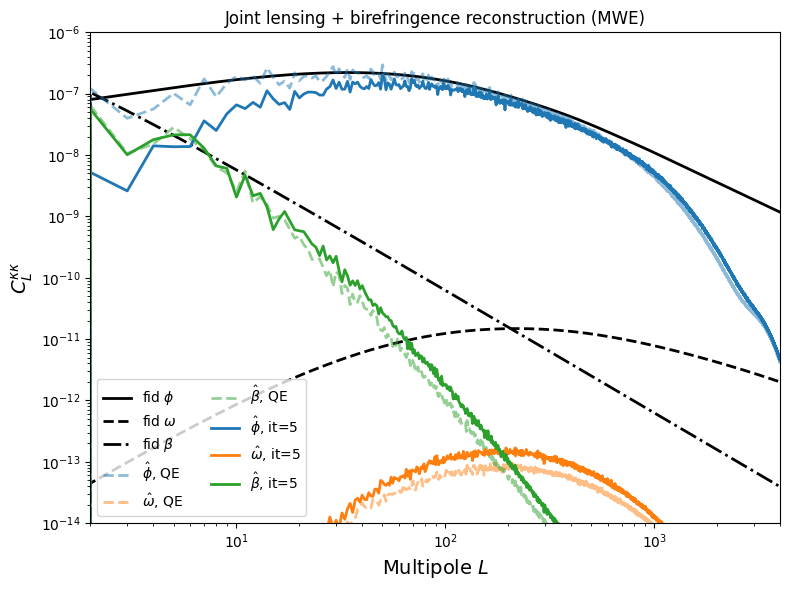

In [9]:
scale = lambda L: (L * (L + 1))**2 / 4   # kappa scaling

fig, ax = plt.subplots(figsize=(8, 6))

# --- fiducial curves ---
ax.plot(LL, scale(LL) * sec_fids[0][0, :LM_max[0]+1],
        color='black', lw=2, ls='-',  label=r'fid $\phi$')
if sec_fids[0].shape[0] > 1:
    ax.plot(LL, scale(LL) * sec_fids[0][1, :LM_max[0]+1],
            color='black', lw=2, ls='--', label=r'fid $\omega$')
if len(sec_fids) > 1:
    ax.plot(LL, sec_fids[1][0, :LM_max[0]+1],
            color='black', lw=2, ls='-.', label=r'fid $\beta$')

# --- reconstructed spectra (single sim, no averaging) ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # phi, omega, beta
labels = [r'\hat{\phi}', r'\hat{\omega}', r'\hat{\beta}']
# flatten with explicit indexing matching your structure
comp_map = [
    (0, 0, r'\hat{\phi}',   True),   # (outer, inner, label, kappa-scale)
    (0, 1, r'\hat{\omega}', True),
    (1, 0, r'\hat{\beta}',  False),
]

for it in its:
    tag   = 'QE' if it == 0 else f'it={it}'
    alpha = 0.5  if it == 0 else 1.0
    ls    = '--' if it == 0 else '-'

    for ci, (oi, ii, label, use_scale) in enumerate(comp_map):
        est_alm = secest[it][oi][ii]
        cl = hp.alm2cl(est_alm)[:LM_max[0]+1]
        ax.plot(LL, cl, color=colors[ci], lw=2,
                alpha=alpha, ls=ls,
                label=fr'${label}$, {tag}')

ax.set_xlim(2, LM_max[0])
ax.set_ylim(1e-14, 1e-6)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Multipole $L$', fontsize=14)
ax.set_ylabel(r'$C_L^{\kappa\kappa}$', fontsize=14)
ax.legend(ncol=2, loc='lower left', fontsize=10)
ax.set_title('Joint lensing + birefringence reconstruction (MWE)')
plt.tight_layout()
plt.show()

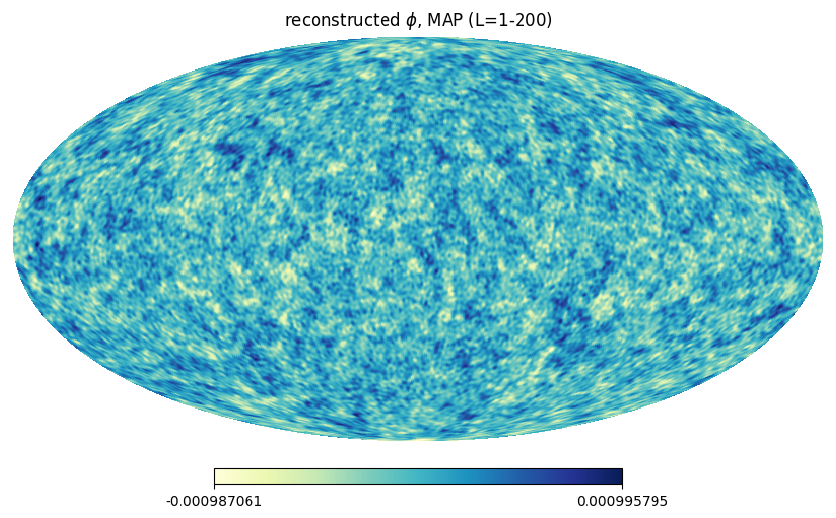

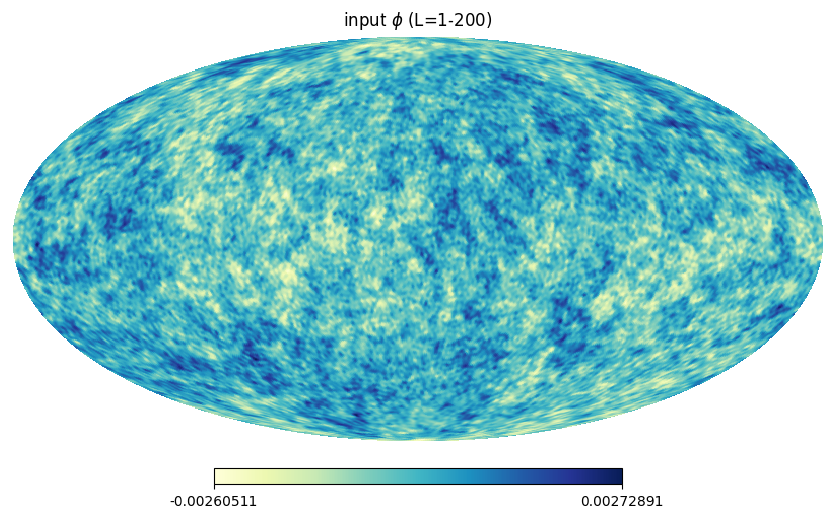

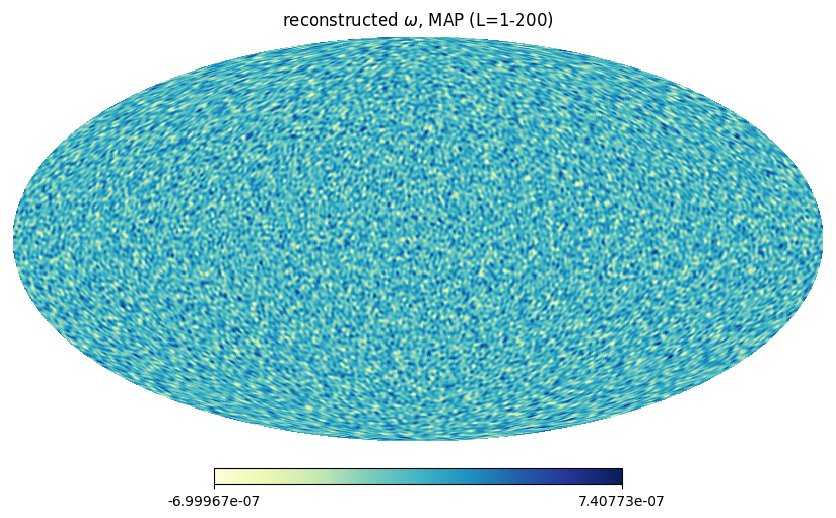

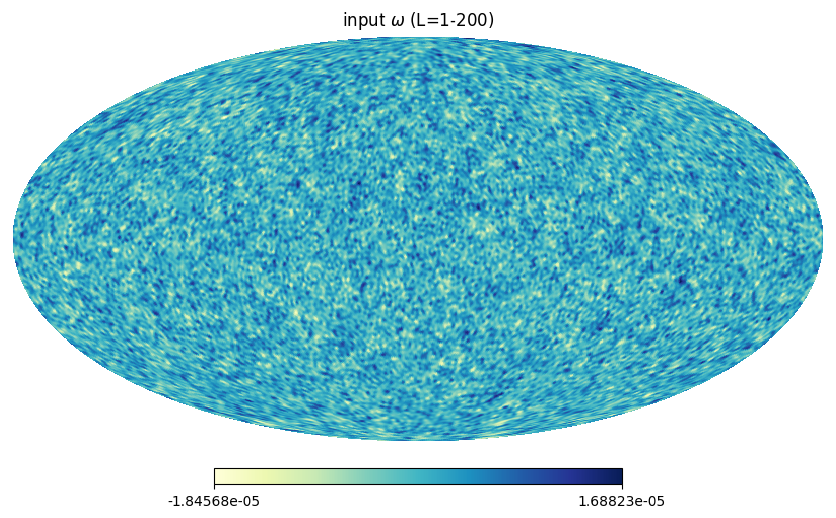

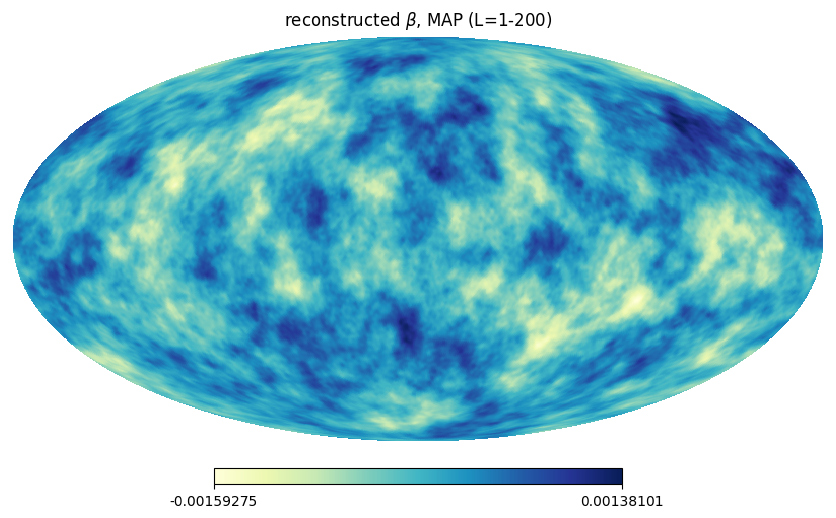

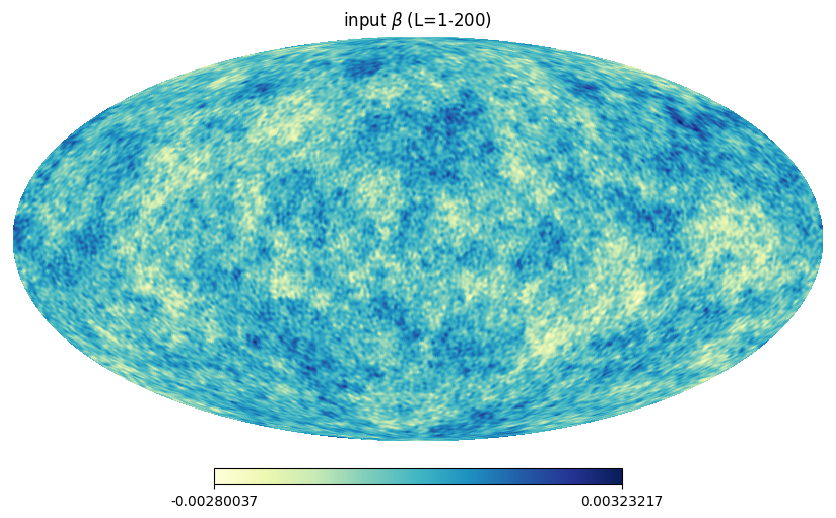

In [16]:
from delensalot.utils import cli
NSIDE  = 256
LMIN   = 1
LMAX   = 200
cmap   = 'YlGnBu'

defl_weight = np.sqrt(LL * (LL + 1))

# (outer, inner, label, deflection-weight)
comp_map = [
    (0, 0, r'\phi',   True),
    (0, 1, r'\omega', True),
    (1, 0, r'\beta',  False),
]

it_MAP  = max(its)
sec_ins = ana.data_container.get_sim_sec(sim_idx, space='alm', return_nonrec=True)

for oi, ii, label, use_defl in comp_map:
    try:
        alm_rec = secest[it_MAP][oi][ii]
        alm_in  = sec_ins[oi][ii]
    except IndexError:
        continue

    weight  = defl_weight if use_defl else np.ones_like(defl_weight)

    map_rec = hp.alm2map(bandpass_alms(hp.almxfl(alm_rec, cli(weight)), LMIN, LMAX), nside=NSIDE)
    map_in  = hp.alm2map(bandpass_alms(hp.almxfl(alm_in,  weight), LMIN, LMAX), nside=NSIDE)

    hp.mollview(map_rec, title=fr'reconstructed ${label}$, MAP (L={LMIN}-{LMAX})', cmap=cmap)
    hp.mollview(map_in,  title=fr'input ${label}$ (L={LMIN}-{LMAX})',              cmap=cmap)
    plt.show()

In [ ]:
# ── 5. B-lensing template & delensing ────────────────────────────────────────
ctx, _ = get_computation_context()
ctx.set(idx=sim_idx, idx2=sim_idx, secondary=['birefringence', 'lensing'])
template_QE  = ana.get_template(idx=sim_idx, it=0,      secondary='lensing', component='p')
template_MAP = ana.get_template(idx=sim_idx, it=it_MAP, secondary='lensing', component='p')



# if it returns a flat tuple/list (Talm, Ealm, Balm):
template_B_QE  = template_QE[2]
template_B_MAP = template_MAP[2]


DEBUG:: 05-17 11:51:01:: delensalot.sims.data_source.get_sim_sky - requestingsky_spacealm_spin0_fieldpolarization_0
DEBUG:: 05-17 11:51:01:: delensalot.sims.data_source.get_sim_sky - ..nothing cached..
DEBUG:: 05-17 11:51:01:: delensalot.sims.data_source.get_sim_sky - .., but stored on disk.
Residual lensing amplitude A_lens:
  QE  delensing: 0.317
  MAP delensing: 0.197


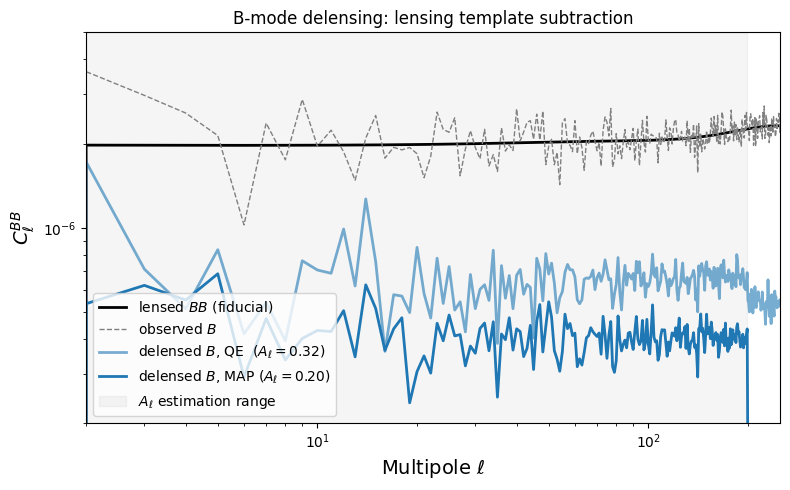

In [ ]:
obs_B_alm = ana.data_container.get_sim_sky(sim_idx, space='alm', field='polarization', spin=0)[1] 


lmax_obs   = hp.Alm.getlmax(obs_B_alm.size)
lmax_templ = hp.Alm.getlmax(template_B_MAP.size)
lmax_use   = min(lmax_obs, lmax_templ)


ana.cls_len = camb_clfile(config.analysis.cls_len)
ana.cl_BB_len = ana.cls_len['bb'][:lmax_use + 1]
obs_B_alm_cut  = alm_copy(obs_B_alm,    None, lmax_use, lmax_use)
templ_QE_cut   = alm_copy(template_B_QE,  None, lmax_use, lmax_use)
templ_MAP_cut  = alm_copy(template_B_MAP, None, lmax_use, lmax_use)

delensed_B_QE  = obs_B_alm_cut - templ_QE_cut
delensed_B_MAP = obs_B_alm_cut - templ_MAP_cut

# all subsequent cls use lmax_templ
ells         = np.arange(lmax_templ + 1)
cl_obs       = hp.alm2cl(obs_B_alm_cut)[:lmax_templ + 1]
cl_delens_QE = hp.alm2cl(delensed_B_QE) [:lmax_templ + 1]
cl_delens_MAP= hp.alm2cl(delensed_B_MAP) [:lmax_templ + 1]
cl_BB_len    = ana.cls_len['bb']          [:lmax_templ + 1]

# --- residual lensing amplitude A_lens ---
Lmin_Alens, Lmax_Alens = 2, 199
mask = (ells >= Lmin_Alens) & (ells <= Lmax_Alens)

def residual_amplitude(cl_res, cl_ref, ells, mask):
    """A_lens: L(L+1)-weighted mean of cl_res / cl_ref."""
    return np.average(cl_res[mask] / cl_ref[mask])

A_lens_QE  = residual_amplitude(cl_delens_QE,  cl_BB_len, ells, mask)
A_lens_MAP = residual_amplitude(cl_delens_MAP, cl_BB_len, ells, mask)

print(f"Residual lensing amplitude A_lens:")
print(f"  QE  delensing: {A_lens_QE:.3f}")
print(f"  MAP delensing: {A_lens_MAP:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ells, cl_BB_len,      color='black',    lw=2,          label=r'lensed $BB$ (fiducial)')
ax.plot(ells, cl_obs,         color='gray',     lw=1, ls='--', label=r'observed $B$')
ax.plot(ells, cl_delens_QE,   color=colors[0],  lw=2, alpha=0.6,
        label=fr'delensed $B$, QE  ($A_\ell={A_lens_QE:.2f}$)')
ax.plot(ells, cl_delens_MAP,  color=colors[0],  lw=2,
        label=fr'delensed $B$, MAP ($A_\ell={A_lens_MAP:.2f}$)')
ax.axvspan(Lmin_Alens, Lmax_Alens, alpha=0.08, color='gray', label=r'$A_\ell$ estimation range')
ax.set_xlim(2, 250)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'Multipole $\ell$', fontsize=14)
ax.set_ylabel(r'$C_\ell^{BB}$', fontsize=14)
ax.set_ylim(2e-7,5e-6)
ax.set_title(r'B-mode delensing: lensing template subtraction')
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.show()